In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv('../../data/processed/dataset_14-23.csv')
trad = pd.read_csv('results/trad_1423.csv')
prob = pd.read_csv('results/prob_1423.csv')
rnn = pd.read_csv('results/rnn_168hr_1423.csv')

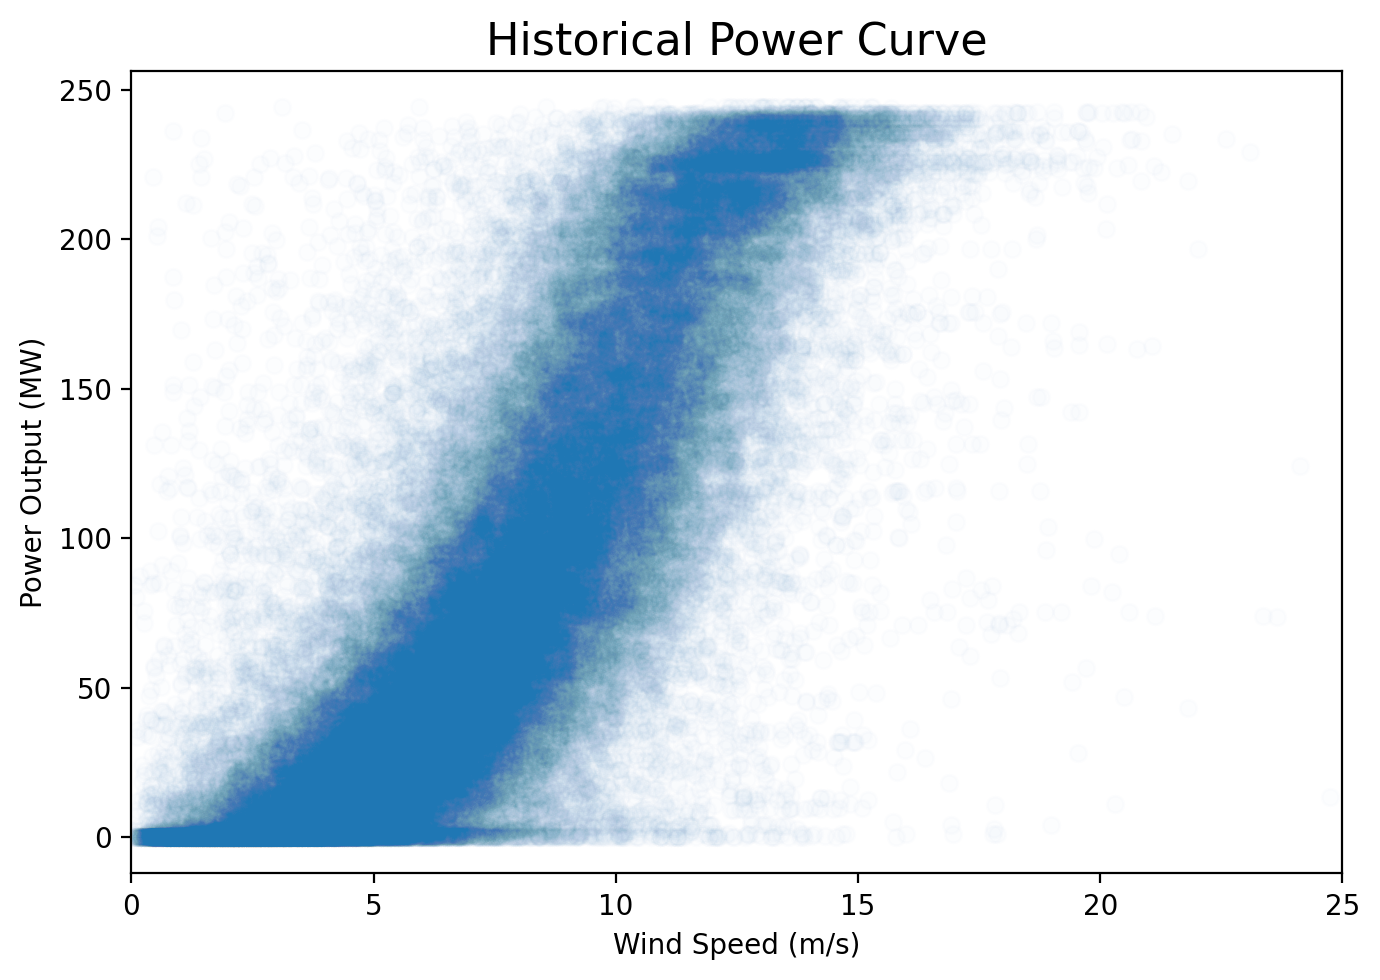

In [97]:
plt.figure(figsize=(7, 5), dpi=200)
plt.scatter(df['speed'], df['power'], alpha=0.01)
plt.title('Historical Power Curve', fontsize=16)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')
plt.xlim(0, 25)
plt.tight_layout()

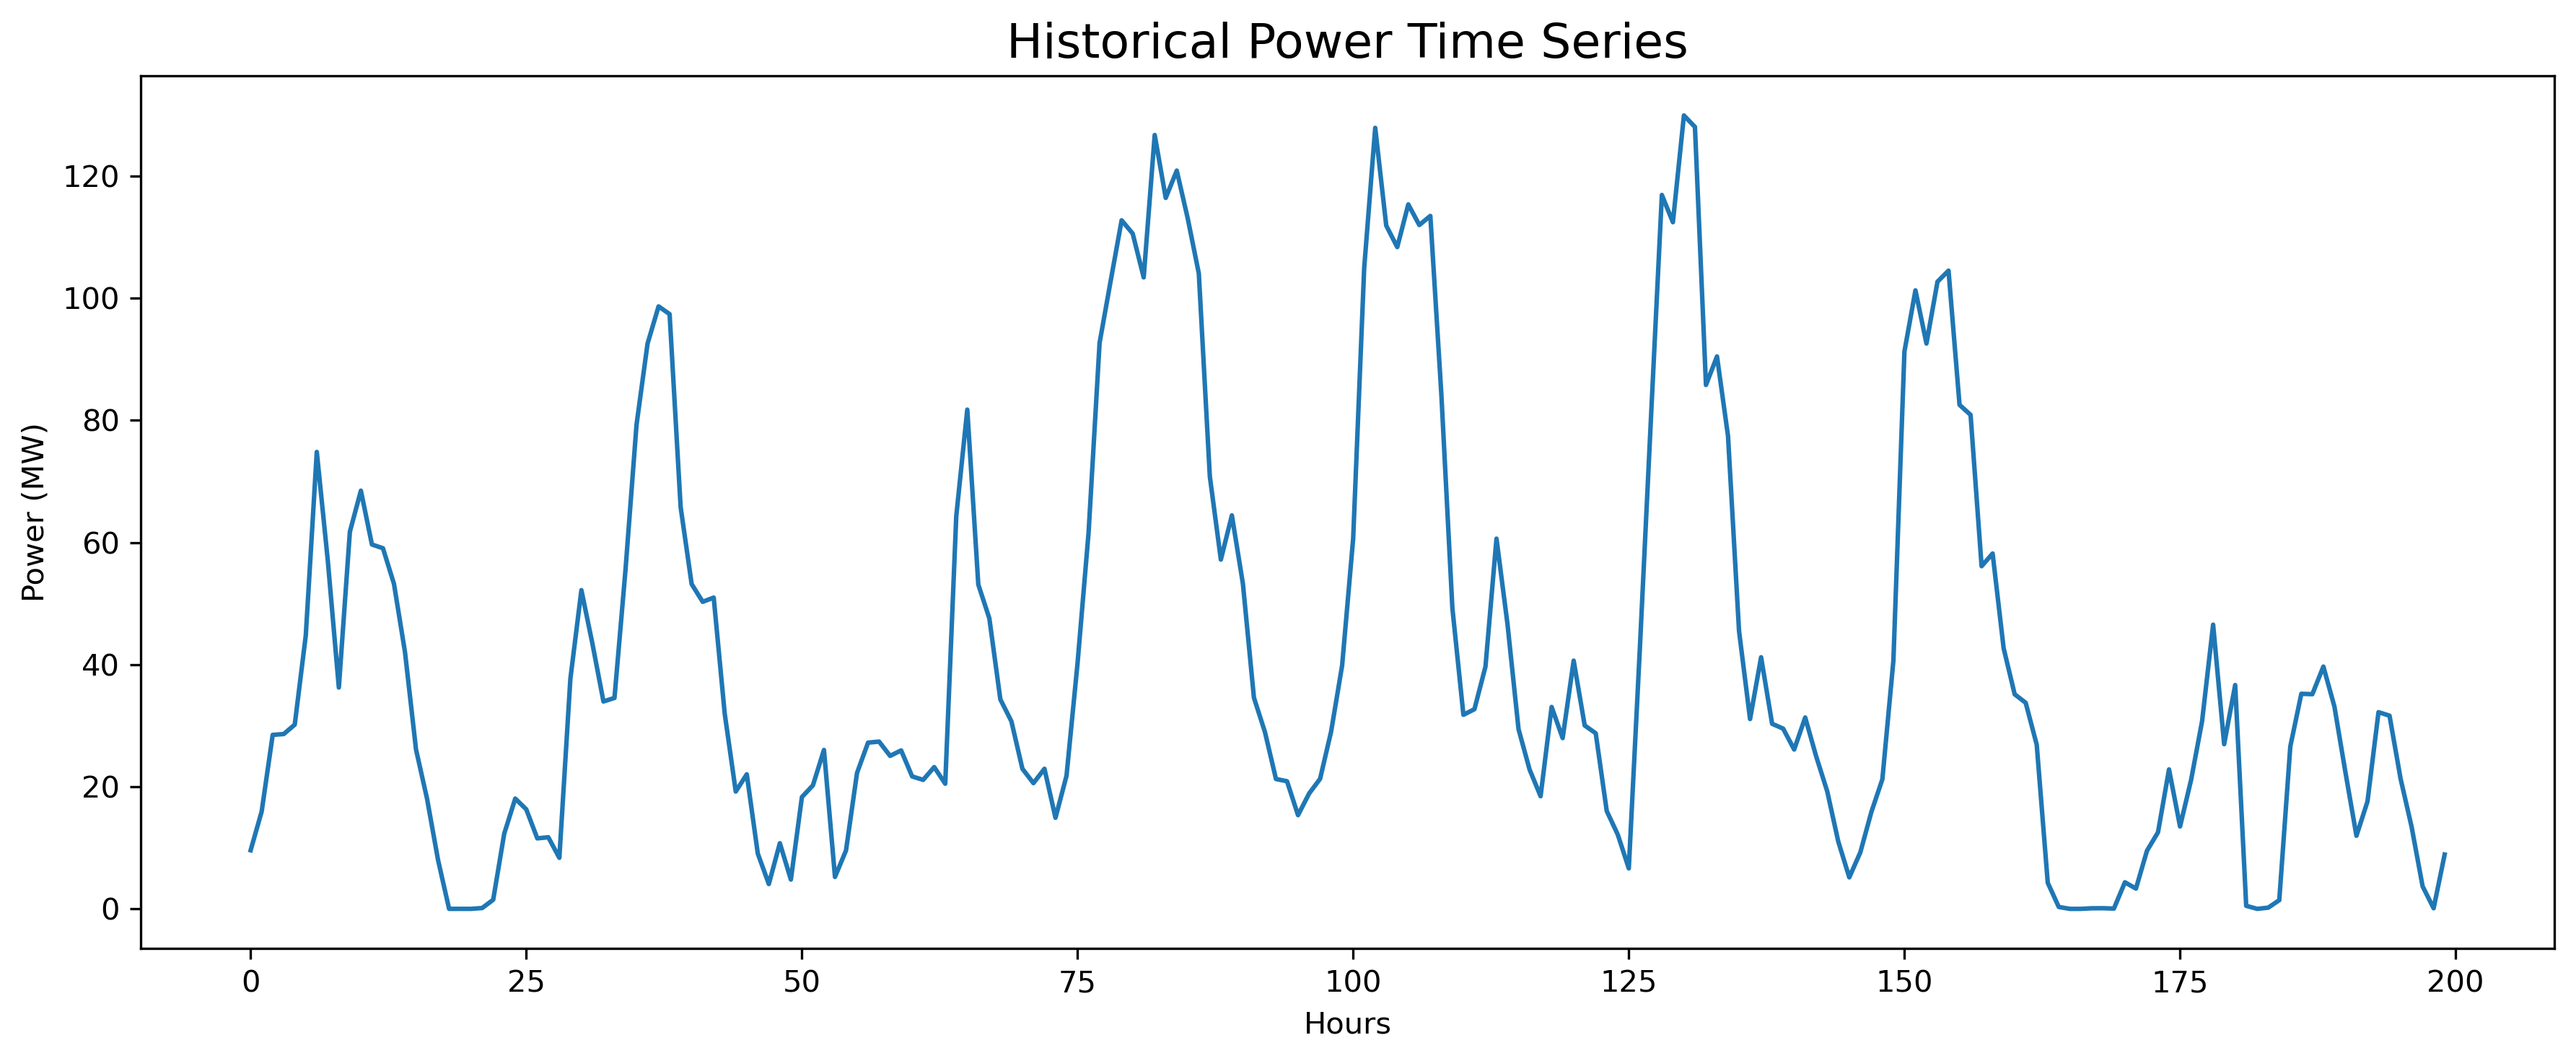

In [107]:
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(df['power'][100:300].reset_index(drop=True))
plt.title('Historical Power Time Series', fontsize=16)
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.tight_layout()

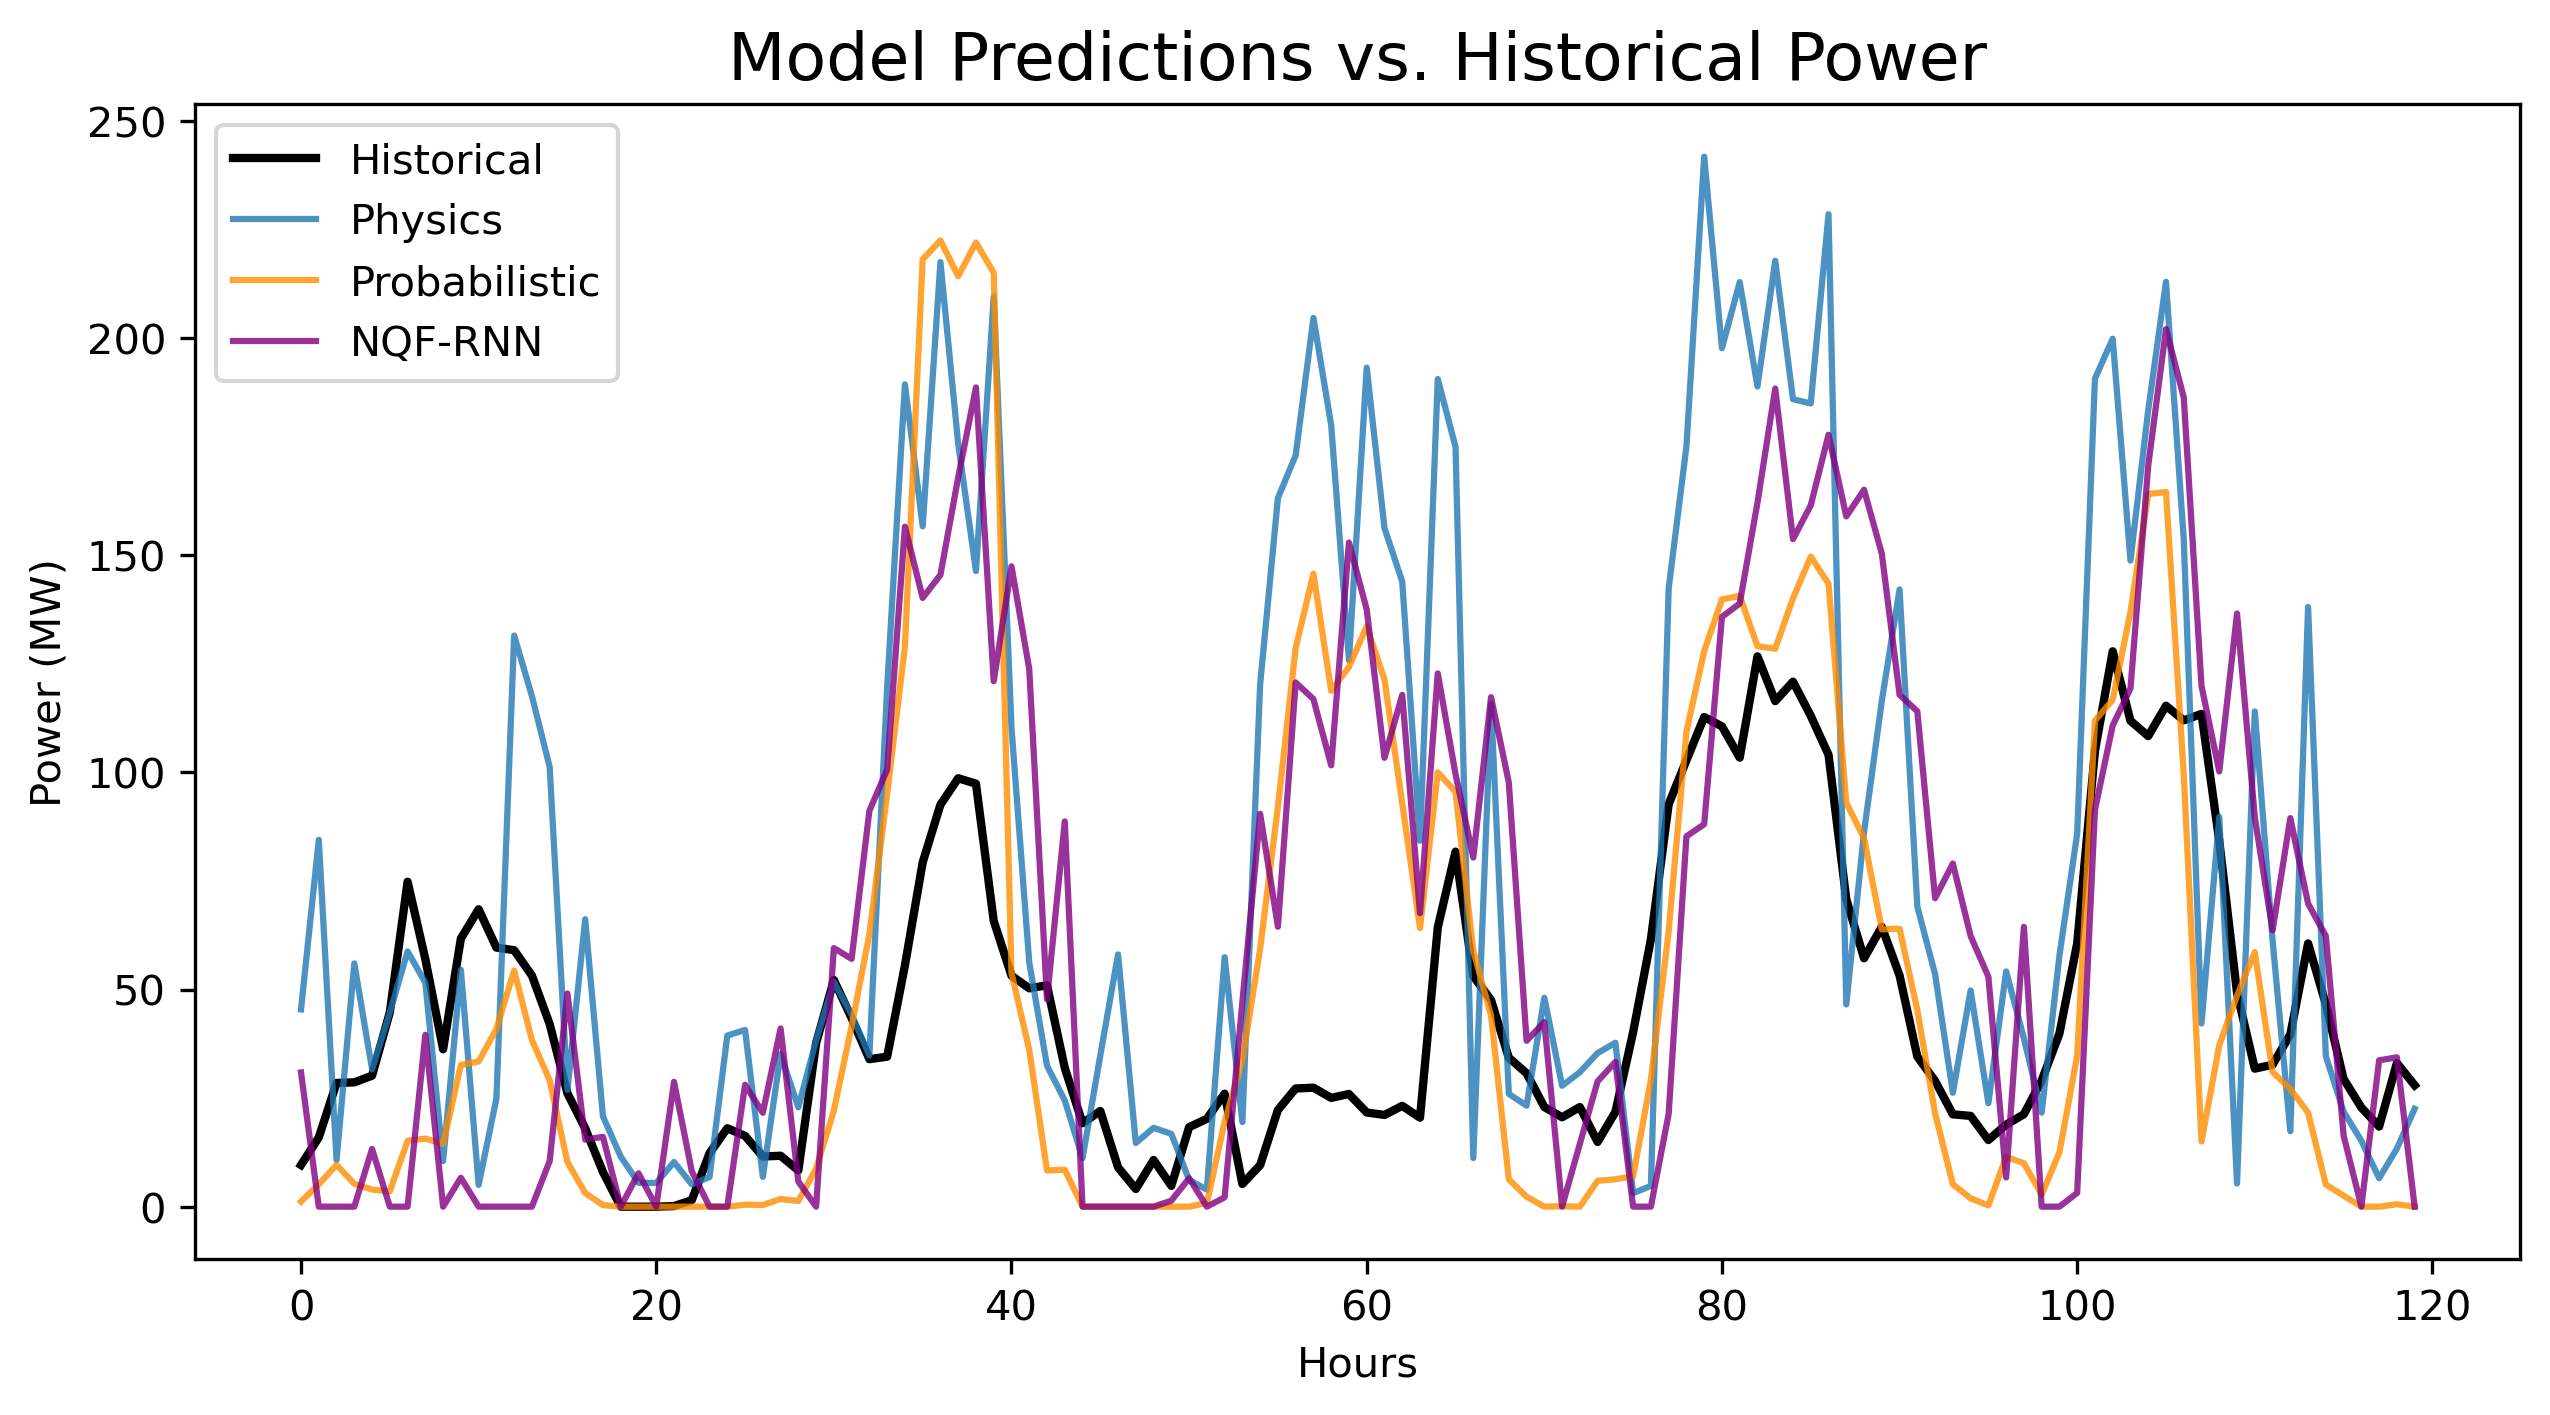

In [131]:
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(df['power'][100:220].reset_index(drop=True), label='Historical', color='black', linewidth=2)
plt.plot(trad['preds'][100:220].reset_index(drop=True), label='Physics', color='tab:blue', alpha=0.8)
plt.plot(prob['preds'][100:220].reset_index(drop=True), label='Probabilistic', color='darkorange', alpha=0.8)
plt.plot(rnn['preds'][100:220].reset_index(drop=True), label='NQF-RNN', color='purple', alpha=0.8)
plt.title('Model Predictions vs. Historical Power', fontsize=16)
plt.xlabel('Hours')
plt.ylabel('Power (MW)')
plt.legend()

# Metrics

In [124]:
# trad, prob, rnn
labels = ['Traditional/Physics', 'Probabilistic', 'NQF-RNN (168hr)']
rmses = [0.224, 0.256, 0.219]
cc = [0.784, 0.644, 0.761]
similarity = [0.752, 0.834, 0.792]

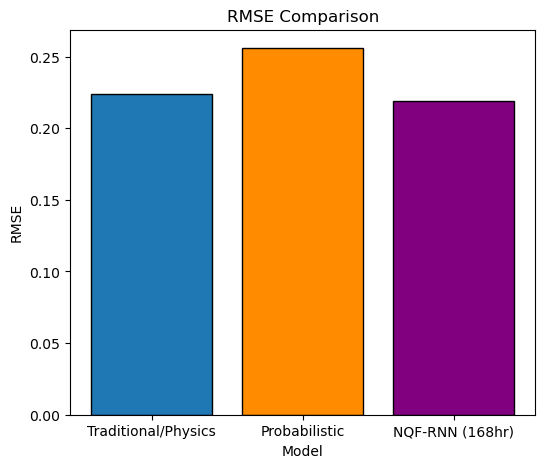

In [125]:
# bar chart for rmses
plt.figure(figsize=(6, 5))
plt.bar(labels, rmses, color=['tab:blue', 'darkorange', 'purple'], edgecolor='black')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.show()

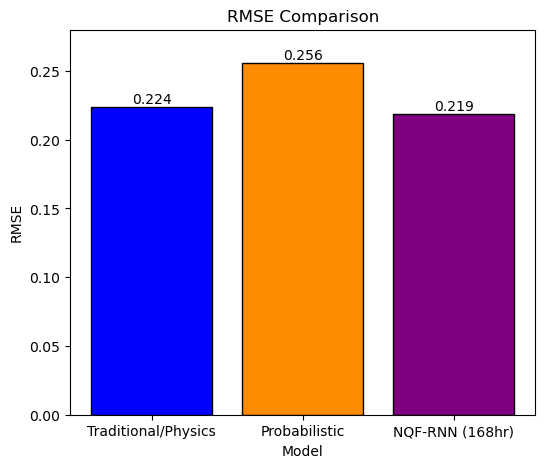

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, rmses, color=['blue', 'darkorange', 'purple'], edgecolor='black')
# ax.bar_label(bars, padding=3, fontsize=10, color='black')
ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_ylim(0, 0.28)
ax.set_title('RMSE Comparison')
for bar, rmse in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{rmse:.3f}', 
            ha='center', va='bottom', fontsize=10, color='black')
plt.show()

# against we-validate

In [100]:
labels = ['NWPDB', 'PLUSWIND', 'Physics', 'Probabilistic', 'NQF-RNN']
rmses = [0.230, 0.199, 0.294, 0.312, 0.178]
cc = [0.808, 0.832, 0.780, 0.601, 0.852]
similarity = [0.577, 0.395, 0.607, 0.601, 0.680]

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_50830/606401944.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


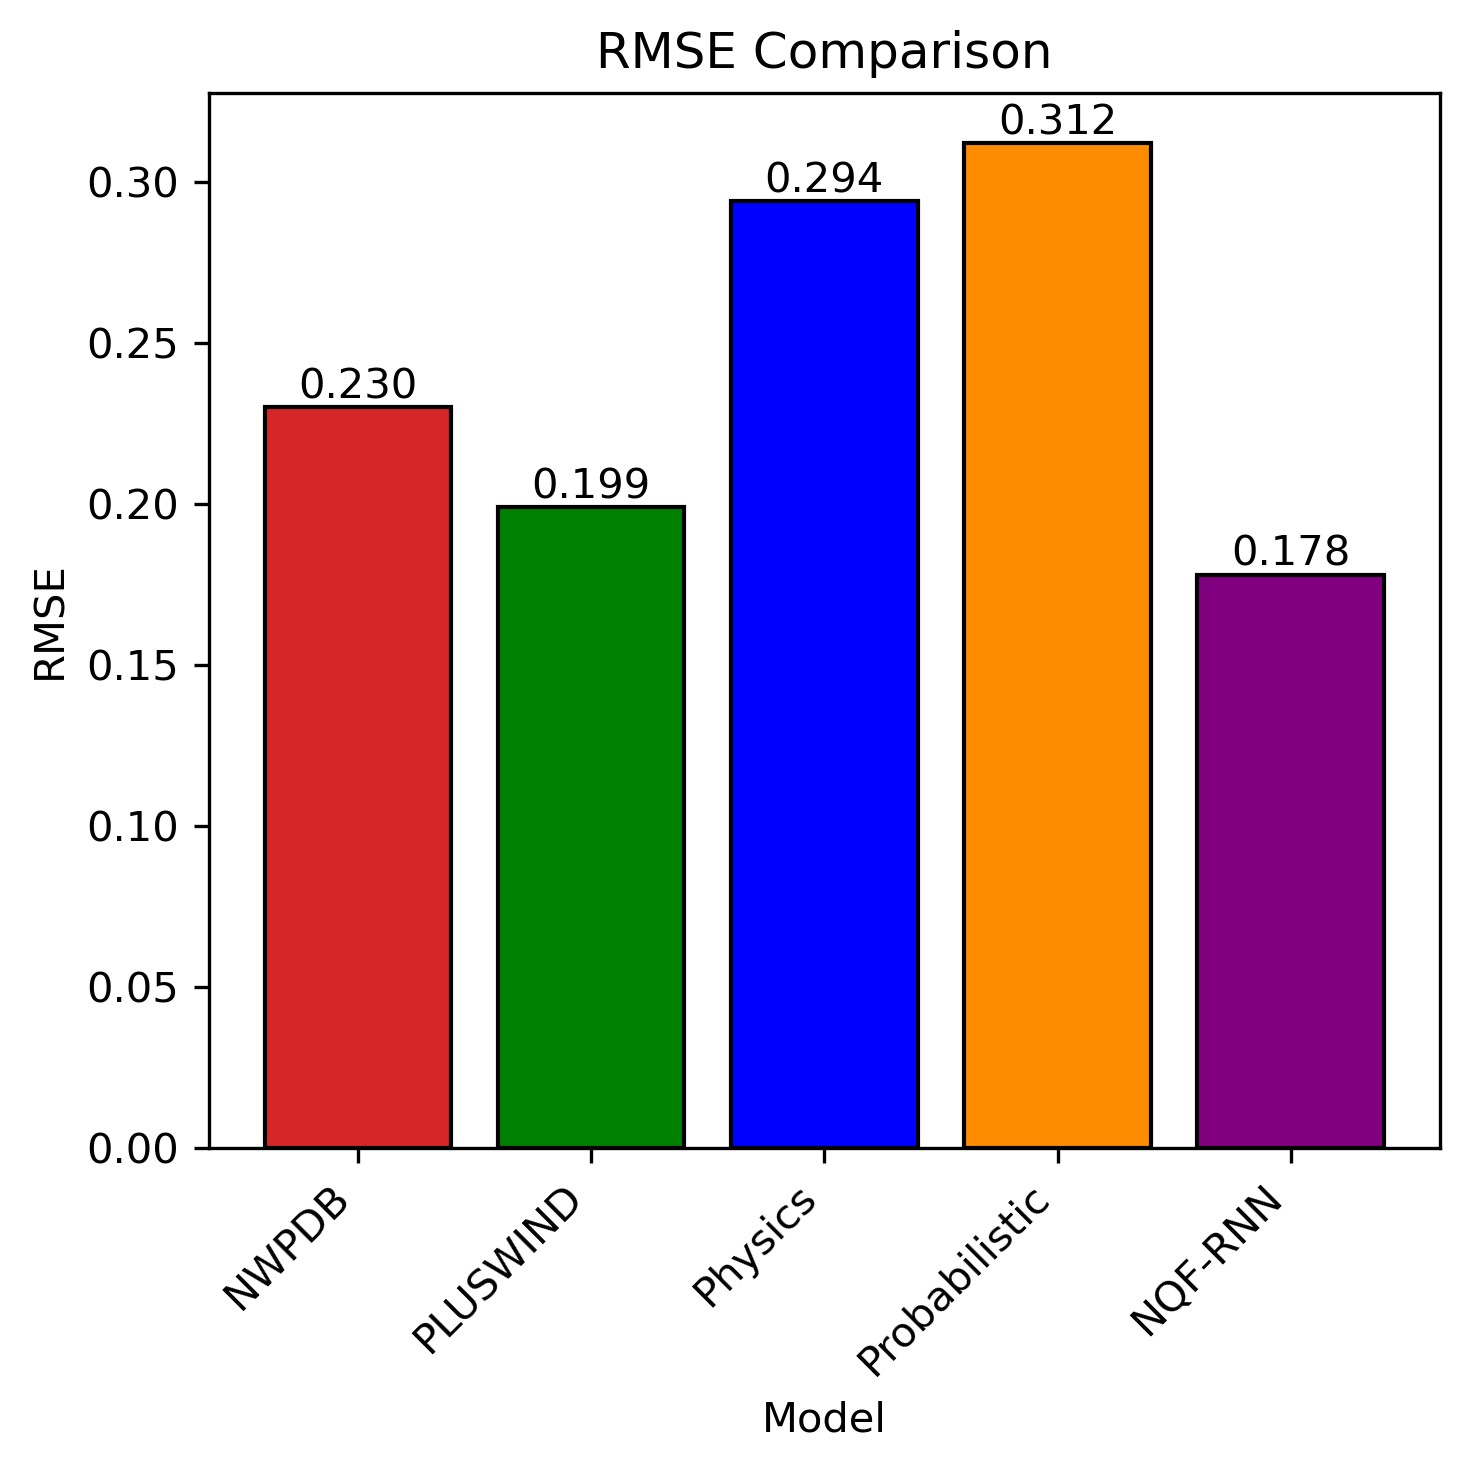

In [101]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
bars = ax.bar(labels, rmses, edgecolor='black', color=['tab:red', 'green', 'blue', 'darkorange', 'purple'])
ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison')
ax.set_xticklabels(labels, rotation=45, ha='right')
for bar, rmse in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{rmse:.3f}', 
            ha='center', va='bottom', fontsize=10, color='black')
plt.tight_layout()
plt.show()

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_50830/955340310.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


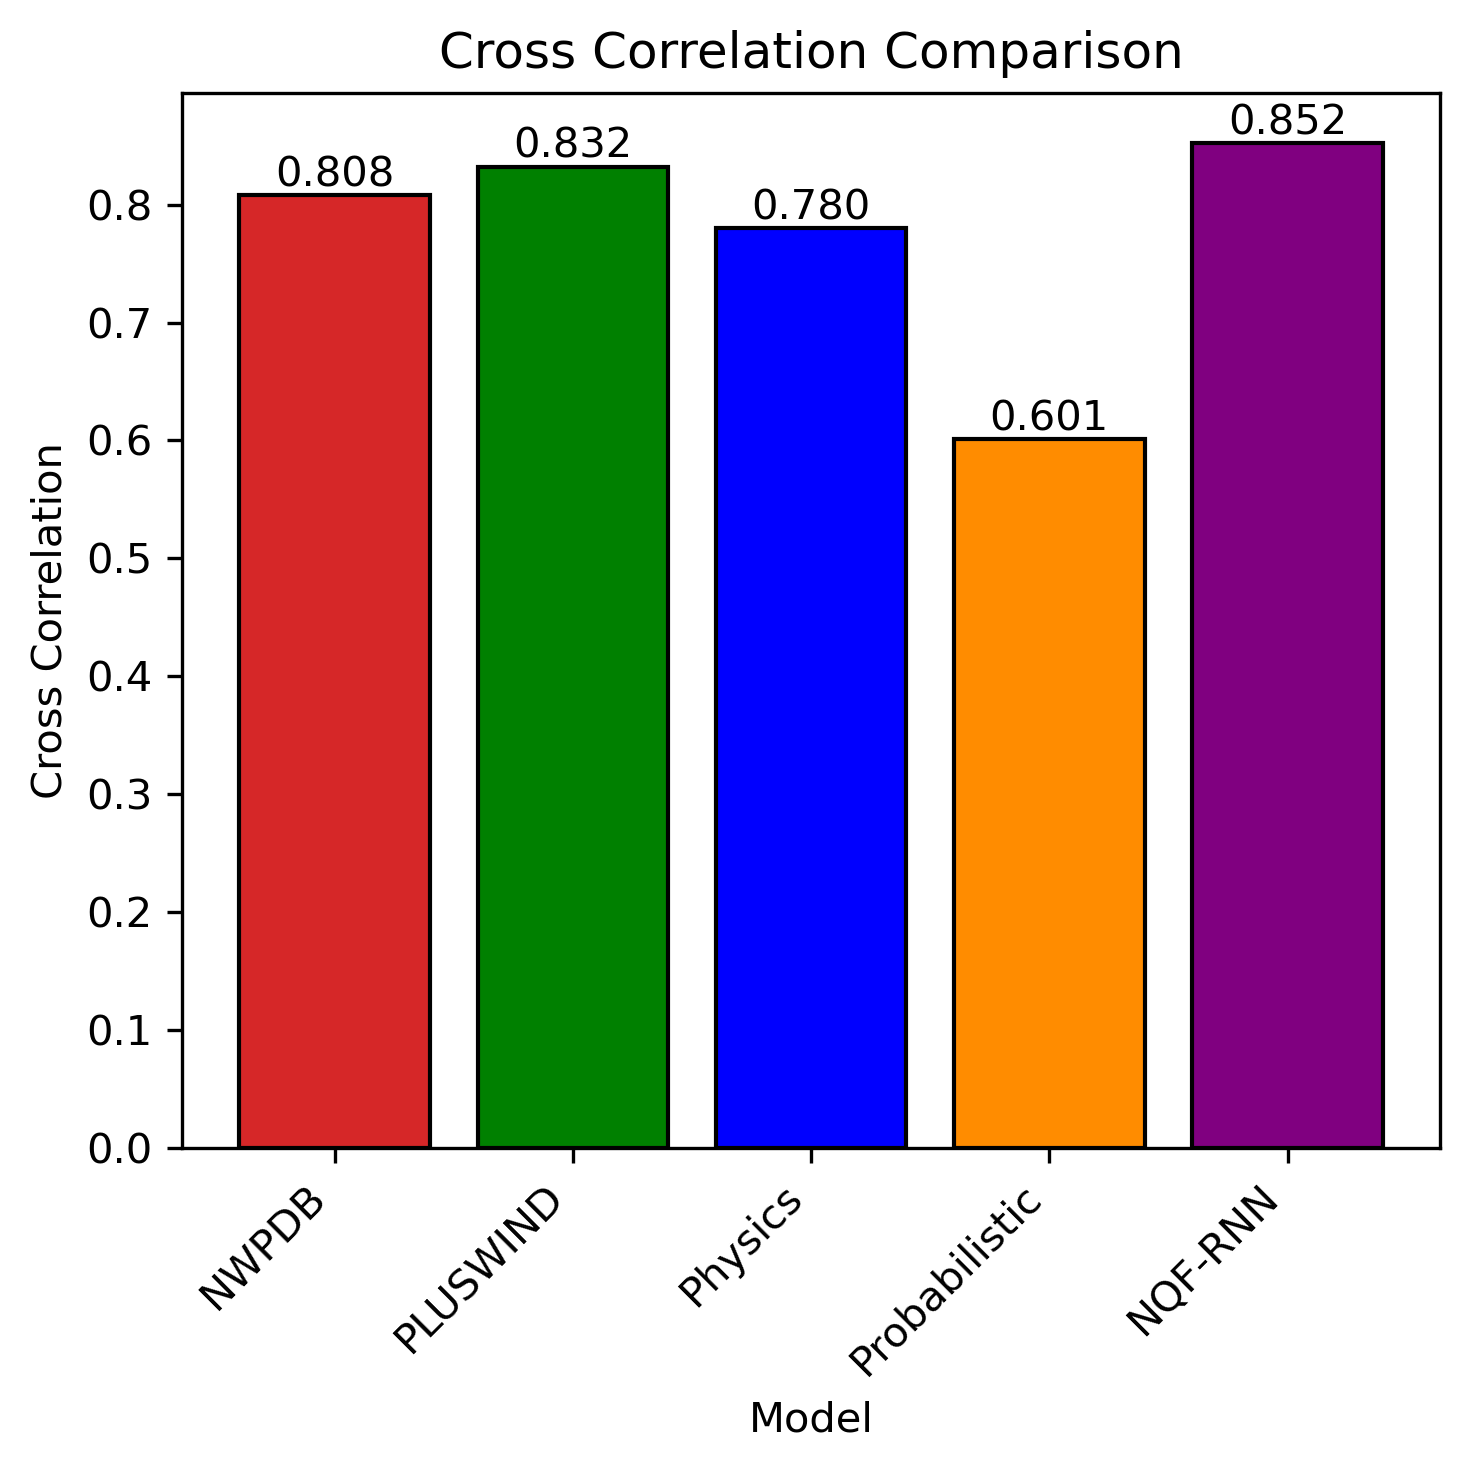

In [102]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
bars = ax.bar(labels, cc, edgecolor='black', color=['tab:red', 'green', 'blue', 'darkorange', 'purple'])
ax.set_xlabel('Model')
ax.set_ylabel('Cross Correlation')
ax.set_title('Cross Correlation Comparison')
ax.set_xticklabels(labels, rotation=45, ha='right')
for bar, cc_value in zip(bars, cc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{cc_value:.3f}', 
            ha='center', va='bottom', fontsize=10, color='black')
plt.tight_layout()
plt.show()

/var/folders/ld/ry50f5bs3tzgqgpbq7z2_6pw0000gn/T/ipykernel_50830/910622130.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


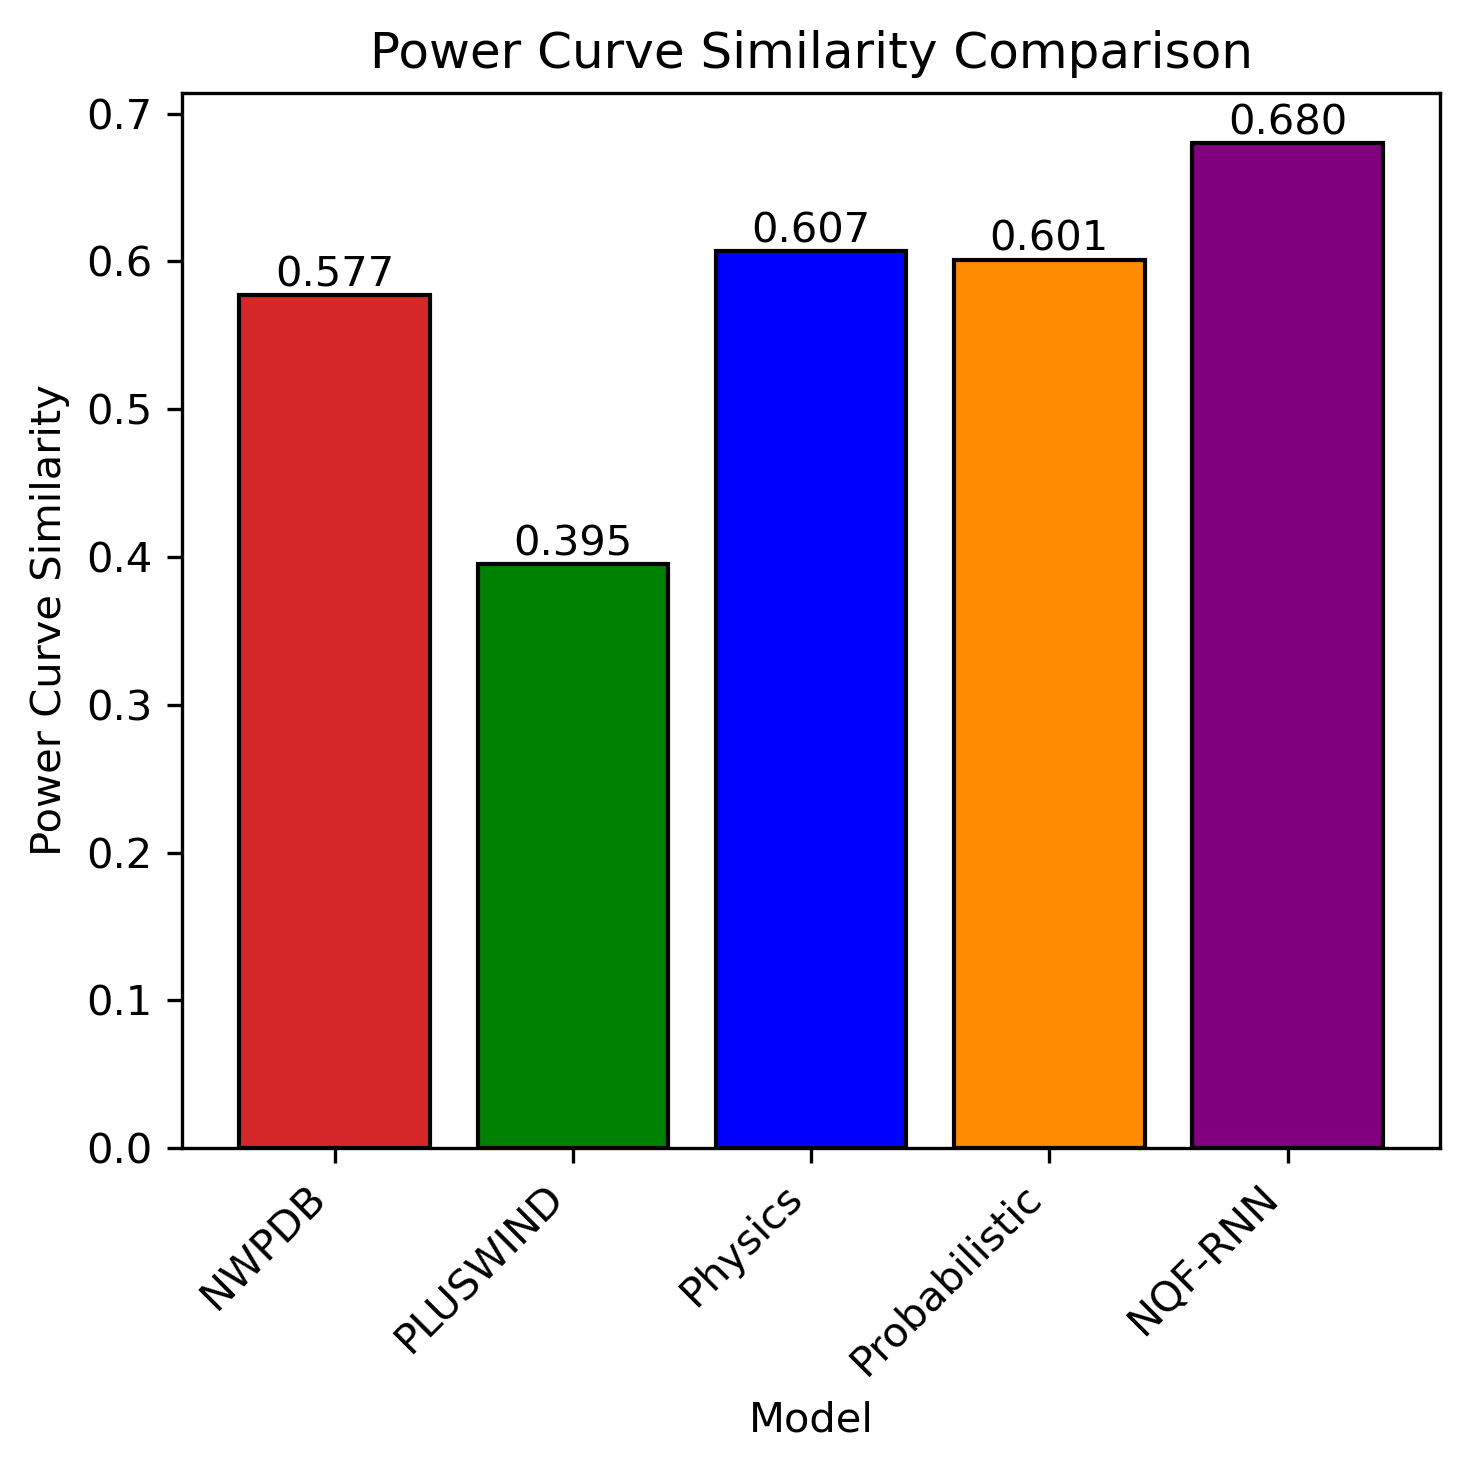

In [103]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
bars = ax.bar(labels, similarity, edgecolor='black', color=['tab:red', 'green', 'blue', 'darkorange', 'purple'])
ax.set_xlabel('Model')
ax.set_ylabel('Power Curve Similarity')
ax.set_title('Power Curve Similarity Comparison')
ax.set_xticklabels(labels, rotation=45, ha='right')
for bar, sim in zip(bars, similarity):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{sim:.3f}', 
            ha='center', va='bottom', fontsize=10, color='black')
plt.tight_layout()
plt.show()